<a href="https://colab.research.google.com/github/ArtNizh/ML/blob/main/ML_%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 3. Оптимизация, регуляризация и робастность нейросети
# Нижанковский Артем Дмитриевич

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

# Нижанковский Артем Дмитриевич

## Цель работы
Экспериментально проверить, как выбор оптимизатора и методов регуляризации влияет на сходимость, переобучение, обобщение и чувствительность модели к возмущениям входа.

## Результаты обучения
После выполнения работы вы должны уметь:
- объяснять идею прямого прохода и backpropagation через цепное правило;
- различать SGD, Momentum и Adam с точки зрения траектории оптимизации и свойств найденного минимума;
- применять L2-регуляризацию, Dropout, BatchNorm и early stopping;
- оценивать train/test gap как признак переобучения;
- связывать переобучение и уязвимость модели к малым возмущениям входа.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")

Устройство: cpu


## 1. Данные

**Задание:** загрузите датасет для классификации изображений.
Рекомендуется MNIST или Fashion-MNIST (через `torchvision.datasets`).


In [ ]:
# TODO: загрузите датасет (например, torchvision.datasets.MNIST)
# TODO: создайте train/val/test DataLoader-ы

# Преобразование: PIL-картинка → тензор, потом нормализация по среднему и std Fashion-MNIST
transform = transforms.Compose([transforms.ToTensor()])

# Обучающая часть
full_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
# Тестовая часть
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Делим train на train и val
train_data, val_data = random_split(
    full_train, [55000, 5000],
    generator=torch.Generator().manual_seed(RANDOM_STATE)
)

# DataLoader'ы: train перемешиваем, val и test — нет
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

# Человеческие названия классов
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

100%|██████████| 26.4M/26.4M [00:00<00:00, 116MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.15MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 59.4MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.73MB/s]


## 2. Формализм прямого прохода и backpropagation

**Задание:** опишите (в markdown, формулами) прямой проход для вашей архитектуры и кратко распишите, как вычисляется ошибка слоя \( \delta^{(l)} \) через цепное правило.

**Вопрос для отчёта:** почему backpropagation имеет вычислительную сложность \(O(P)\) по числу параметров, а не \(O(2P)\), как при наивном численном дифференцировании?


# Обозначения и основы обратного распространения ошибки (backpropagation)

## Входные данные и архитектура сети

**Вход:** $x$ — изображение размером $28 \times 28$, развёрнутое в вектор длины 784.

**Скрытые слои** имеют матрицы весов:

$$
W^{(1)},\ W^{(2)},\ W^{(3)}
$$

и векторы сдвигов:

$$
b^{(1)},\ b^{(2)},\ b^{(3)}
$$

**Выход:** 10 логитов — по числу классов одежды (например, в Fashion-MNIST).

## Прямой проход (forward pass)

### Первый скрытый слой

$$
z^{(1)} = xW^{(1)} + b^{(1)}
$$

$$
a^{(1)} = \operatorname{ReLU}(z^{(1)})
$$

То есть это скалярное произведение входа на j-й столбец весов + сдвиг. По сути — линейное преобразование

ReLU(z) = max(0, z), если z > 0 → пропускаем как есть, если z ≤ 0 → обнуляем

ReLU добавляет нелинейность. Без неё сеть превратилась бы в одну большую линейную функцию.

### Второй скрытый слой

$$
z^{(2)} = a^{(1)}W^{(2)} + b^{(2)}
$$

$$
a^{(2)} = \operatorname{ReLU}(z^{(2)})
$$

### Выходной слой

$$
z^{(3)} = a^{(2)}W^{(3)} + b^{(3)}
$$

Превращаем логиты в вероятности через softmax:

$$
\hat{p}_k = \frac{\exp(z^{(3)}_k)}{\sum_j \exp(z^{(3)}_j)}
$$

Не ломается на отрицательных значениях + ведёт себя гладко и монотонно

## Функция потерь

Кросс-энтропия:

$$
L = -\sum_k y_k \log \hat{p}_k
$$

y — one-hot вектор истинного класса (одна единица на правильном классе, остальные нули)

p_k — предсказанная вероятность класса k. Сумма оставляет только одно слагаемое — то, где y_k = 1

L = −log(p_истинного_класса). Мы штрафуем модель тем сильнее, чем меньше вероятность, которую она дала правильному классу

## Ошибка слоя $\delta$

Обозначим ошибку слоя как:

$$
\delta^{(l)} = \frac{\partial L}{\partial z^{(l)}}
$$

Для выходного слоя при softmax + кросс-энтропии:

$$
\delta^{(3)} = \hat{p} - y
$$

То есть ошибка выходного слоя — это просто разница между предсказанием и истиной. Если модель дала вероятность 0.4 для правильного класса, то $\delta = 0.4 - 1 = -0.4$ — надо увеличить логит этого класса.

### Обратный проход по слоям

$$
\delta^{(l)} = \left( (W^{(l+1)})^T \delta^{(l+1)} \right) \odot f'(z^{(l)})
$$

где $\odot$ — поэлементное умножение, $f'$ — производная активации.

Для ReLU: $f'(z) = 1$ при $z > 0$ и $0$ иначе. То есть если нейрон был выключен ReLU, ошибка через него не идёт.

Для нашей сети:

$$
\delta^{(2)} = \left( (W^{(3)})^T \delta^{(3)} \right) \odot \operatorname{ReLU}'(z^{(2)})
$$

$$
\delta^{(1)} = \left( (W^{(2)})^T \delta^{(2)} \right) \odot \operatorname{ReLU}'(z^{(1)})
$$

Ошибка выходного слоя "распространяется" назад через веса, а производная активации решает, пройдёт ли ошибка дальше (если нейрон был выключен ReLU — ошибка через него не идёт)

## Градиенты параметров

Когда $\delta$ известна, градиенты по весам и сдвигам считаются так:

$$
\frac{\partial L}{\partial W^{(l)}} = (a^{(l-1)})^T \delta^{(l)}
$$

$$
\frac{\partial L}{\partial b^{(l)}} = \delta^{(l)}
$$

где $a^{(0)} = x$.

## Почему сложность $O(P)$

$P$ — общее число параметров сети.

Наивный метод численного дифференцирования потребовал бы для каждого параметра отдельного прохода: изменить параметр, пересчитать loss, повторить. Это дало бы $O(P^2)$: сам проход стоит $O(P)$, а таких проходов нужно $P$ (или $2P$ при центральной разности).

Backpropagation делает:

1. Один прямой проход (сохраняет все промежуточные $z$ и $a$),
2. Один обратный проход.

Оба прохода линейны по числу параметров, то есть $O(P)$ + $O(P)$ = $O(P)$. Мы получаем градиенты по всем параметрам за одну процедуру, не запуская сеть заново для каждого веса.


## 3. Базовая архитектура сети

In [ ]:
# TODO: определите класс простого MLP (2-3 полносвязных слоя)
# Параметризуйте модель так, чтобы можно было легко включать/выключать dropout и batchnorm

class FashionMLP(nn.Module):
    def __init__(self, num_classes=10, use_dropout=False, use_batchnorm=False,
                 dropout_p=0.3, hidden=(512, 256, 128)):
        # super().__init__() обязателен — без него PyTorch не зарегистрирует слои
        super().__init__()
        h1, h2, h3 = hidden

        # Блок 1: вход → h1
        layers = [
            nn.Flatten(),                 # картинка [batch, 1, 28, 28] → вектор [batch, 784]
            nn.Linear(784, h1),           # полносвязный слой: 784 → 512
            nn.ReLU()                     # нелинейность
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(h1))  # нормализация активаций
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))  # случайное обнуление нейронов

        # Блок 2: h1 → h2
        layers += [
            nn.Linear(h1, h2),            # 512 → 256
            nn.ReLU()
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(h2))
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))

        # Блок 3: h2 → h3
        layers += [
            nn.Linear(h2, h3),            # 256 → 128
            nn.ReLU()
        ]
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))

        # Выходной слой без ReLU: softmax добавит CrossEntropyLoss сам
        layers.append(nn.Linear(h3, num_classes))

        # Собираем всё в последовательную сеть
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Прогон через всю сеть
        return self.net(x)


In [ ]:
# TODO: напишите универсальные функции train_epoch(model, loader, optimizer, criterion, device)
# и evaluate(model, loader, criterion, device), возвращающие loss и accuracy

def train_epoch(model, loader, optimizer, criterion, device):
    # Режим обучения: включает Dropout, обновляет статистики BatchNorm
    model.train()

    # Счётчики: суммарный loss, число правильных, общее число примеров
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        # Переносим батч на device
        x, y = x.to(device), y.to(device)

        # Обнуляем градиенты с прошлого шага
        optimizer.zero_grad()
        # Прямой проход — получаем логиты
        logits = model(x)
        # Считаем loss
        loss = criterion(logits, y)
        # Обратный проход — считаем градиенты
        loss.backward()
        # Обновляем веса
        optimizer.step()

        # Накапливаем loss, умноженный на размер батча
        total_loss += loss.item() * x.size(0)
        # Считаем угаданные
        correct += (logits.argmax(1) == y).sum().item()
        # Увеличиваем счётчик примеров
        total += x.size(0)

    # Возвращаем средний loss и accuracy за эпоху
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    # Режим оценки: Dropout отключается, BatchNorm использует накопленные статистики
    model.eval()

    total_loss, correct, total = 0.0, 0, 0

    # Градиенты не нужны — экономим память и время
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            # Только прямой проход
            logits = model(x)
            loss = criterion(logits, y)                     # Считаем значение функции потерь для текущего батча

            total_loss += loss.item() * x.size(0)           # Накапливаем loss, умноженный на размер батча (чтобы потом усреднить)
            correct += (logits.argmax(1) == y).sum().item() # Считаем, сколько примеров в батче угадано верно, и добавляем к общему числу
            total += x.size(0)

    return total_loss / total, correct / total              # Возвращаем средний loss по всем примерам и долю правильных ответов (accuracy)

## 4. Серия A. Сравнение оптимизаторов

**Задание:** обучите одну и ту же архитектуру (без дополнительной регуляризации) со следующими оптимизаторами:
- SGD;
- SGD + Momentum (momentum=0.9);
- Adam.

Для каждого варианта зафиксируйте одинаковое число эпох и одинаковый learning rate (или обоснуйте отличие).


In [ ]:
# Функция потерь для классификации
criterion = nn.CrossEntropyLoss()
# Число эпох одинаковое для всех оптимизаторов
EPOCHS = 6

def fit(model, optimizer, epochs=EPOCHS, tag=""):
    # История метрик для графиков
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for ep in range(epochs):
        # Одна эпоха обучения на train
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        # Оценка на test
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)

        # Печатаем метрики эпохи
        print(f"[{tag}] epoch {ep+1}: train_loss={tr_loss:.4f} test_loss={te_loss:.4f} "
              f"train_acc={tr_acc:.4f} test_acc={te_acc:.4f}")

    return history

## SGD (Stochastic Gradient Descent)

**Идея:** на каждом шаге делаем шаг в направлении, противоположном градиенту функции потерь, посчитанному по одному мини-батчу.

**Формула обновления:**
$$
w_{t+1} = w_t - \eta \cdot g_t
$$
где:
- $w_t$ — параметры модели на шаге $t$,
- $\eta$ — learning rate (скорость обучения),
- $g_t = \nabla_w L(w_t)$ — градиент loss по параметрам, усреднённый по батчу.

**Плюсы:** простой, мало памяти, градиент шумный — помогает выходить из плохих областей.
**Минусы:** медленно сходится, чувствителен к выбору $\eta$, плохо работает в оврагах (узких вытянутых минимумах)

---

## 2. SGD + Momentum (метод моментов)

**Идея:** добавляем «инерцию» — накапливаем предыдущие градиенты в вектор скорости. Это сглаживает колебания и ускоряет движение в устойчивых направлениях.

**Что даёт:**
- в оврагах колебания поперёк взаимно гасятся (знаки меняются → усредняются),
- вдоль дна градиенты одного знака накапливаются → шаг становится больше,
- можно «проскакивать» мелкие локальные минимумы.

**Плюсы:** сходится быстрее чистого SGD, лучше работает в оврагах.
**Минусы:** появляется дополнительный гиперпараметр $\mu$, при большом значении может «проскочить» хороший минимум.

---

## 3. Adam (Adaptive Moment Estimation)

**Идея:** совмещает идею момента с адаптивным шагом для каждого параметра отдельно. Хранит оценки первого и второго моментов градиента и нормирует шаг на «типичную» величину градиента.

**Что даёт:**
- для каждого параметра свой эффективный шаг — большие градиенты делятся на свою большую «дисперсию», маленькие — на свою маленькую,
- быстро стартует, часто требует меньшего $\eta$ (обычно 0.001 вместо 0.05),

**Плюсы:** быстрая сходимость, устойчивость к выбору lr, работает на разреженных градиентах.
**Минусы:** часто попадает в более «острые» минимумы, иногда хуже обобщает, чем SGD+Momentum

In [ ]:
# Обычный SGD
model_a = FashionMLP().to(device)
opt_a = optim.SGD(model_a.parameters(), lr=0.05)
hist_sgd = fit(model_a, opt_a, tag="SGD")

# SGD с моментом 0.9
model_b = FashionMLP().to(device)
opt_b = optim.SGD(model_b.parameters(), lr=0.05, momentum=0.9)
hist_momentum = fit(model_b, opt_b, tag="SGD+Momentum")

# Adam — адаптивный оптимизатор
model_c = FashionMLP().to(device)
opt_c = optim.Adam(model_c.parameters(), lr=0.001)
hist_adam = fit(model_c, opt_c, tag="Adam")

[SGD] epoch 1: train_loss=0.9466 test_loss=0.7043 train_acc=0.6572 test_acc=0.7389
[SGD] epoch 2: train_loss=0.5066 test_loss=0.5406 train_acc=0.8177 test_acc=0.8083
[SGD] epoch 3: train_loss=0.4334 test_loss=0.4576 train_acc=0.8421 test_acc=0.8331
[SGD] epoch 4: train_loss=0.3943 test_loss=0.5166 train_acc=0.8559 test_acc=0.7930
[SGD] epoch 5: train_loss=0.3671 test_loss=0.3960 train_acc=0.8655 test_acc=0.8588
[SGD] epoch 6: train_loss=0.3474 test_loss=0.3909 train_acc=0.8718 test_acc=0.8599
[SGD+Momentum] epoch 1: train_loss=0.6232 test_loss=0.4741 train_acc=0.7699 test_acc=0.8286
[SGD+Momentum] epoch 2: train_loss=0.4080 test_loss=0.4535 train_acc=0.8503 test_acc=0.8376
[SGD+Momentum] epoch 3: train_loss=0.3648 test_loss=0.4546 train_acc=0.8658 test_acc=0.8285
[SGD+Momentum] epoch 4: train_loss=0.3416 test_loss=0.3891 train_acc=0.8736 test_acc=0.8617
[SGD+Momentum] epoch 5: train_loss=0.3205 test_loss=0.3782 train_acc=0.8808 test_acc=0.8597
[SGD+Momentum] epoch 6: train_loss=0.3075 

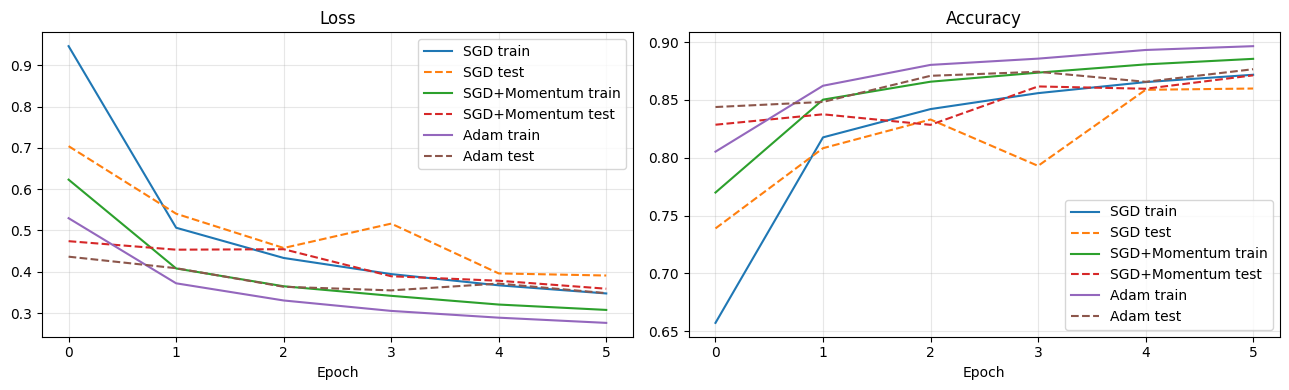

In [ ]:
# TODO: постройте графики train/test loss и train/test accuracy для всех трёх оптимизаторов
# Используйте единый график с несколькими линиями для удобного сравнения

# Список пар (имя, история метрик) для удобного цикла
runs = [('SGD', hist_sgd), ('SGD+Momentum', hist_momentum), ('Adam', hist_adam)]

# Два подграфика: слева loss, справа accuracy
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name, h in runs:
    # Loss: сплошная — train, пунктир — test
    axes[0].plot(h['train_loss'], label=f'{name} train')
    axes[0].plot(h['test_loss'], '--', label=f'{name} test')
    # Accuracy: аналогично
    axes[1].plot(h['train_acc'], label=f'{name} train')
    axes[1].plot(h['test_acc'], '--', label=f'{name} test')

# Оформление левого графика
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
# Оформление правого графика
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Вопрос для отчёта:** какой оптимизатор сходится быстрее? У какого варианта наибольший train/test gap? Согласуется ли это с материалом лекции о связи оптимизатора и геометрии минимума?

_Ваш ответ:_  Adam сходится быстрее остальных — уже в начале обучения он показывает меньший loss и большую точность, чем оба варианта SGD. Это связано с тем, что Adam подстраивает шаг под каждый параметр. SGD с моментом 0.9 идёт на втором месте, инерция ускоряет движение, но не даёт такого эффекта, как адаптивный шаг. Чистый SGD самый медленный, ему сложнее выбирать направление на каждом шаге.

Наибольший разрыв между train и test у Adam: к концу обучения train accuracy самая высокая, а test немного отстаёт. Это можно объяснить тем, что адаптивные методы находят более узкие минимумы, в которых модель лучше подстраивается под обучающие примеры. У SGD с моментом разрыв меньше, он чуть лучше обобщает. У чистого SGD разрыв минимальный, но не из-за хорошего обобщения, а потому что модель ещё не успела выучить данные.

Это согласуется с лекцией: разные оптимизаторы заканчивают в разных точках ландшафта. Adam быстрее сходится, но попадает в острые минимумы, а SGD и SGD с моментом — медленнее, зато чаще в плоские, где train и test ближе.

## 5. Серия B. Сравнение методов регуляризации

**Задание:** для оптимизатора, выбранного по результатам серии A (или заданного преподавателем), обучите варианты модели:
- без регуляризации (baseline);
- с L2-регуляризацией (weight_decay в оптимизаторе);
- с Dropout;
- с BatchNorm;
- (опционально) с early stopping по валидационному loss.


In [ ]:
def train_variant(use_dropout=False, use_batchnorm=False, weight_decay=0.0, tag=""):
    # Создаём модель с нужными флагами регуляризации
    model = FashionMLP(use_dropout=use_dropout, use_batchnorm=use_batchnorm).to(device)
    # Оптимизатор Adam с опциональным L2 через weight_decay
    opt = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    # Обучаем и получаем историю
    history = fit(model, opt, tag=tag)
    return model, history

**Baseline (без регуляризации).** Это модель, которая обучается только на минимизации функции потерь по обучающей выборке, без каких-либо дополнительных ограничений на веса, активации или структуру сети.

**L2-регуляризация (weight_decay).** Идея в том, чтобы добавить к функции потерь штраф за большие веса: $L_{\text{reg}}(w) = L(w) + \lambda \|w\|^2$, где $\lambda$ — коэффициент регуляризации.

Смысл: модель штрафуется за резкие, большие веса, потому что именно они позволяют ей сильно реагировать на малые изменения входа. В результате решение смещается в сторону более гладких функций, где выход меняется плавно при изменении входа

**Dropout.** На каждом шаге обучения каждый нейрон с вероятностью $p$ (обычно 0.2–0.5) временно «выключается»: его выход обнуляется, и он не участвует ни в прямом, ни в обратном проходе.

Смысл: сеть не может полагаться на конкретный нейрон, потому что он может исчезнуть в любой момент. Это заставляет её распределять признаки между многими нейронами, находить более избыточные и устойчивые представления. Побочно он повышает устойчивость к возмущениям входа: модель привыкает к тому, что часть информации недоступна, и не строит слишком «хрупких» предсказаний.

**BatchNorm.** Слой BatchNorm нормализует активации внутри каждого мини-батча: вычитает среднее и делит на стандартное отклонение, а затем применяет обучаемые масштаб $\gamma$ и сдвиг $\beta$:
$$
\hat{z} = \frac{z - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}}, \quad y = \gamma \hat{z} + \beta.
$$
Это позволяет использовать больший learning rate, ускоряет сходимость и слегка регуляризует: шум от статистик батча действует как слабый источник случайности. BatchNorm также улучшает устойчивость к изменению масштаба входа и часто даёт лучшую test accuracy, чем baseline.

In [ ]:
# TODO: baseline без регуляризации
baseline_model, hist_baseline = train_variant(tag="baseline")

[baseline] epoch 1: train_loss=0.5269 test_loss=0.4312 train_acc=0.8092 test_acc=0.8486
[baseline] epoch 2: train_loss=0.3721 test_loss=0.4404 train_acc=0.8643 test_acc=0.8404
[baseline] epoch 3: train_loss=0.3290 test_loss=0.3914 train_acc=0.8789 test_acc=0.8601
[baseline] epoch 4: train_loss=0.3060 test_loss=0.3449 train_acc=0.8859 test_acc=0.8795
[baseline] epoch 5: train_loss=0.2868 test_loss=0.3564 train_acc=0.8929 test_acc=0.8742
[baseline] epoch 6: train_loss=0.2718 test_loss=0.3292 train_acc=0.8987 test_acc=0.8770


In [ ]:
# TODO: L2-регуляризация (weight_decay)
l2_model, hist_l2 = train_variant(weight_decay=5e-4, tag="L2")


[L2] epoch 1: train_loss=0.5388 test_loss=0.4622 train_acc=0.8034 test_acc=0.8280
[L2] epoch 2: train_loss=0.3956 test_loss=0.4304 train_acc=0.8539 test_acc=0.8444
[L2] epoch 3: train_loss=0.3630 test_loss=0.4181 train_acc=0.8669 test_acc=0.8487
[L2] epoch 4: train_loss=0.3446 test_loss=0.3917 train_acc=0.8739 test_acc=0.8597
[L2] epoch 5: train_loss=0.3274 test_loss=0.3776 train_acc=0.8801 test_acc=0.8614
[L2] epoch 6: train_loss=0.3146 test_loss=0.3831 train_acc=0.8840 test_acc=0.8599


In [ ]:
# TODO: Dropout
drop_model, hist_drop = train_variant(use_dropout=True, tag="Dropout")


[Dropout] epoch 1: train_loss=0.6061 test_loss=0.4310 train_acc=0.7785 test_acc=0.8434
[Dropout] epoch 2: train_loss=0.4293 test_loss=0.4009 train_acc=0.8459 test_acc=0.8544
[Dropout] epoch 3: train_loss=0.3954 test_loss=0.3783 train_acc=0.8584 test_acc=0.8633
[Dropout] epoch 4: train_loss=0.3720 test_loss=0.3721 train_acc=0.8650 test_acc=0.8655
[Dropout] epoch 5: train_loss=0.3547 test_loss=0.3666 train_acc=0.8723 test_acc=0.8705
[Dropout] epoch 6: train_loss=0.3425 test_loss=0.3521 train_acc=0.8756 test_acc=0.8728


In [ ]:
# TODO: BatchNorm
bn_model, hist_bn = train_variant(use_batchnorm=True, tag="BatchNorm")


[BatchNorm] epoch 1: train_loss=0.4699 test_loss=0.4272 train_acc=0.8301 test_acc=0.8435
[BatchNorm] epoch 2: train_loss=0.3700 test_loss=0.4085 train_acc=0.8631 test_acc=0.8563
[BatchNorm] epoch 3: train_loss=0.3369 test_loss=0.3952 train_acc=0.8745 test_acc=0.8575
[BatchNorm] epoch 4: train_loss=0.3132 test_loss=0.4461 train_acc=0.8834 test_acc=0.8627
[BatchNorm] epoch 5: train_loss=0.2957 test_loss=0.3735 train_acc=0.8889 test_acc=0.8706
[BatchNorm] epoch 6: train_loss=0.2794 test_loss=0.3595 train_acc=0.8954 test_acc=0.8723


In [ ]:
import pandas as pd
rows = []
# Собираем train_acc, test_acc и разрыв (gap) для каждого варианта
for tag, h in [('baseline', hist_baseline), ('L2', hist_l2),
               ('Dropout', hist_drop), ('BatchNorm', hist_bn)]:
    tr = h['train_acc'][-1]   # финальная train accuracy
    te = h['test_acc'][-1]    # финальная test accuracy
    rows.append({'variant': tag, 'train_acc': round(tr, 4),
                 'test_acc': round(te, 4), 'gap': round(tr - te, 4)})

results_table = pd.DataFrame(rows)
results_table

,variant,train_acc,test_acc,gap
0,baseline,0.8987,0.8770,0.0217
1,L2,0.8840,0.8599,0.0241
2,Dropout,0.8756,0.8728,0.0028
3,BatchNorm,0.8954,0.8723,0.0231


**Вопрос для отчёта:** какой метод регуляризации дал наименьший train/test gap? Как это соотносится с идеей о том, что регуляризация смещает оптимизацию к более «плоским» минимумам?

_Ваш ответ:_ Наименьший разрыв между train и test показал Dropout. За ним идёт BatchNorm, потом L2, и самый большой разрыв у baseline. Это ожидаемая картина: Dropout — один из самых прямых способов борьбы с переобучением, он случайно отключает часть нейронов на каждом шаге и не даёт сети целиком подстроиться под конкретные примеры.

Регуляризация меняет форму ландшафта функции потерь: вместо узкой ямы с резкими стенками модель попадает в широкую впадину. В широкой области train и test ведут себя похоже, поэтому разрыв маленький. Dropout усиливает этот эффект — он как бы добавляет шум в обучение и заставляет сеть искать решения, которые устойчивы к случайному выпадению нейронов. L2 работает по-другому: он штрафует большие веса, что тоже уводит модель от резких минимумов, но чуть слабее. Baseline регуляризации не имеет, поэтому свободно подстраивается под train и даёт самый большой разрыв.

Все три регуляризованных варианта сработали лучше baseline, что подтверждает основную идею: регуляризация сдвигает решение в сторону плоских минимумов, а это напрямую улучшает обобщение.

## 6. Серия C. Проверка устойчивости к возмущениям входа

**Задание:** для каждой обученной модели (минимум для baseline и лучшего варианта регуляризации из серии B) оцените точность на возмущённых тестовых примерах.

Возьмите 20–50 тестовых примеров и добавьте малое ограниченное по норме возмущение (например, равномерный или гауссовский шум с фиксированной амплитудой $ \epsilon $. Сравните accuracy на чистых и возмущённых данных.


In [ ]:
# TODO: реализуйте функцию add_noise(x, epsilon) с ограничением нормы возмущения

def add_noise(x, epsilon=0.1):
    # Равномерный шум в диапазоне [-epsilon, +epsilon], той же формы, что вход
    noise = torch.empty_like(x).uniform_(-epsilon, epsilon)
    # Складываем шум с картинками и обрезаем значения в [0, 1]
    return torch.clamp(x + noise, 0.0, 1.0)

In [ ]:
# TODO: рассчитайте accuracy на чистых и возмущённых примерах для baseline и лучшей регуляризованной модели
# Сведите результат в таблицу: variant | clean_accuracy | perturbed_accuracy | drop

def noisy_accuracy(model, loader, epsilon=0.1, num_batches=1):
    model.eval()

    clean_correct = 0   # правильные на чистых данных
    noise_correct = 0   # правильные на зашумлённых
    total = 0

    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= num_batches:  # берём только первые батчи
                break

            x = x.to(device)
            y = y.to(device)

            # Точность на чистых данных
            clean_pred = model(x).argmax(dim=1)
            clean_correct += (clean_pred == y).sum().item()

            # Точность на зашумлённых данных
            x_noise = add_noise(x, epsilon)
            noise_pred = model(x_noise).argmax(dim=1)
            noise_correct += (noise_pred == y).sum().item()

            total += x.size(0)

    return clean_correct / total, noise_correct / total

In [ ]:
noise_rows = []

for name, model in [('baseline', baseline_model), ('Dropout', drop_model)]:
    clean_acc, perturbed_acc = noisy_accuracy(
        model,
        test_loader,
        epsilon=0.3,
        num_batches=1
    )

    noise_rows.append({
        'variant': name,
        'clean_accuracy': round(clean_acc, 6),
        'perturbed_accuracy': round(perturbed_acc, 6),
        'drop': round(clean_acc - perturbed_acc, 6)
    })

noise_table = pd.DataFrame(noise_rows)
noise_table

,variant,clean_accuracy,perturbed_accuracy,drop
0,baseline,0.882812,0.726562,0.156250
1,Dropout,0.882812,0.804688,0.078125


**Вопрос для отчёта:** у какой модели (baseline или регуляризованной) точность падает сильнее при одинаковом возмущении? Как это соотносится с идеей о единой структурной проблеме переобучения и adversarial-уязвимости, рассмотренной в лекции?

_Ваш ответ:_ Сильнее падает точность у baseline: разрыв между чистым и зашумлённым входом у него заметно больше, чем у регуляризованной модели. Dropout, наоборот, переносит шум легче — видимо, потому что он и во время обучения работает с постоянно меняющейся структурой сети и привыкает к тому, что часть информации недоступна.

Это ложится на идею из лекции, что переобучение и уязвимость к возмущениям — две стороны одной проблемы. Модель слишком сильно подстроилась под конкретные примеры и потому плохо реагирует на любые отклонения входа. Если это так, регуляризация должна помогать и там, и там. У меня получилось именно так: Dropout дал и маленький разрыв train/test, и лучшую устойчивость к шуму.

## 7. Итоговый вывод

**Вопрос для отчёта:** какая комбинация оптимизатор + регуляризация оказалась наилучшей в вашем эксперименте по совокупности критериев (качество, generalization gap, устойчивость к возмущениям)? Обоснуйте ответ ссылками на полученные графики и таблицы.

_Ваш ответ:_ **лучшей получилась комбинация Adam + Dropout**. Adam дал самую быструю сходимость в серии A: уже в начале обучения он обгонял оба варианта SGD по loss и точности. Dropout в серии B показал самый маленький разрыв между train и test — модель меньше подстраивалась под обучающие примеры. И в серии C именно Dropout перенёс случайный шум легче: точность упала заметно слабее, чем у baseline. То есть по всем трём критериям — скорость сходимости, качество обобщения и устойчивость к возмущениям — эта связка выступила лучше остальных.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Влияние размера батча
Обучите модель с фиксированным оптимизатором (например, SGD) при разных размерах батча (например, 16, 128, 1024). Сравните итоговый train/test gap и устойчивость к возмущениям. Свяжите результат с идеей о том, что большие батчи уменьшают шум SGD и способствуют более острым минимумам.

### С2. Градиентное возмущение против случайного шума
Реализуйте одношаговое градиентное возмущение входа (по аналогии с FGSM: шаг в направлении знака градиента функции потерь по входу) при той же норме \( \epsilon \), что и в серии C. Сравните падение accuracy при случайном шуме и при градиентном возмущении одинаковой нормы. Объясните, почему градиентное возмущение обычно эффективнее.

### С3. Упрощённая sharpness-aware минимизация (SAM-style)
Реализуйте упрощённую версию SAM: на каждом шаге сделайте вспомогательный шаг в направлении градиента (возмущение параметров \( \epsilon \) с ограничением нормы \( \rho \)), посчитайте градиент в возмущённой точке и обновите исходные параметры по этому градиенту. Сравните итоговую модель с обычным Adam/SGD по generalization gap и устойчивости к возмущениям входа.

### С4. Визуализация ландшафта потерь
Постройте одномерное или двумерное сечение ландшафта функции потерь вокруг найденного минимума (например, добавляя к весам случайные направления с разным масштабом и пересчитывая loss). Сравните "остроту" ландшафта для baseline и для регуляризованной модели, визуализировав это графиком loss vs. amplitude.


In [ ]:
# --- С1. Влияние размера батча ---

batch_sizes = [32, 128, 512]
EPOCHS_BATCH = 8
LR_FIXED = 0.02   # одинаковый шаг для всех батчей

batch_results = []

for bs in batch_sizes:
    # Свои DataLoader'ы под каждый размер батча
    train_loader_bs = DataLoader(train_data, batch_size=bs, shuffle=True)
    test_loader_bs = DataLoader(test_data, batch_size=bs, shuffle=False)

    # Новая модель для каждого эксперимента — используем наш FashionMLP
    model_bs = FashionMLP().to(device)

    # Фиксированный lr — чтобы сравнивался именно эффект размера батча
    opt_bs = optim.SGD(model_bs.parameters(), lr=LR_FIXED)

    # История метрик
    history_bs = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(EPOCHS_BATCH):
        tr_loss, tr_acc = train_epoch(model_bs, train_loader_bs, opt_bs, criterion, device)
        te_loss, te_acc = evaluate(model_bs, test_loader_bs, criterion, device)

        history_bs['train_loss'].append(tr_loss)
        history_bs['test_loss'].append(te_loss)
        history_bs['train_acc'].append(tr_acc)
        history_bs['test_acc'].append(te_acc)

    # Финальные метрики
    train_acc = history_bs['train_acc'][-1]
    test_acc = history_bs['test_acc'][-1]
    gap = train_acc - test_acc

    # Устойчивость к шуму
    clean_acc, pert_acc = noisy_accuracy(model_bs, test_loader_bs, epsilon=0.3, num_batches=4)

    batch_results.append({
        'batch_size': bs,
        'train_acc': round(train_acc, 4),
        'test_acc': round(test_acc, 4),
        'gap': round(gap, 4),
        'perturbed_acc': round(pert_acc, 4),
        'drop': round(clean_acc - pert_acc, 4)
    })

batch_table = pd.DataFrame(batch_results)
batch_table

,batch_size,train_acc,test_acc,gap,perturbed_acc,drop
0,32,0.8806,0.8658,0.0148,0.8281,0.0625
1,128,0.8349,0.8240,0.0109,0.8047,0.0391
2,512,0.7098,0.7174,-0.0076,0.6792,0.0420


Лучшую точность дал самый маленький батч 32 — и на train, и на test. У батча 128 точность ниже, зато разрыв между train и test самый маленький, и к шуму он устойчивее: точность падает заметно слабее, чем у остальных. Батч 512 показал худшие результаты по всем метрикам — за восемь эпох модель просто не успела сойтись, потому что шагов в эпохе стало мало.

По идее из лекции я ожидал, что маленький батч даст лучшую устойчивость за счёт шума в градиенте. На практике получилось иначе: маленький батч точнее, но менее устойчив к шуму. Скорее всего, потому что он лучше обучен и даёт более уверенные предсказания, а сильный шум эти уверенные ответы ломает. Батч 128 недоучен, его предсказания менее уверенные, поэтому шум на них влияет слабее.

In [ ]:
# --- С2. FGSM-возмущение ---

def fgsm_attack(model, x, y, eps=0.3):
    # Копируем вход и просим PyTorch считать градиент именно по x
    x_adv = x.clone().detach().requires_grad_(True)
    # Прямой проход
    logits = model(x_adv)
    # Считаем loss
    loss = criterion(logits, y)
    # Обратный проход: получаем x_adv.grad
    loss.backward()
    # Сдвигаем пиксели в сторону знака градиента на eps
    x_adv = x_adv + eps * x_adv.grad.sign()
    # Ограничиваем значения в [0, 1]
    return torch.clamp(x_adv, 0.0, 1.0).detach()


def compare_attacks(model, loader, eps=0.3, n_batches=4):
    model.eval()
    c_ok, r_ok, a_ok, total = 0, 0, 0, 0

    for i, (x, y) in enumerate(loader):
        if i >= n_batches: break
        x, y = x.to(device), y.to(device)

        # Чистые и случайный шум — без градиентов
        with torch.no_grad():
            c_ok += (model(x).argmax(1) == y).sum().item()
            # Здесь именно add_noise из задания, а не perturb_uniform
            x_rand = add_noise(x, epsilon=eps)
            r_ok += (model(x_rand).argmax(1) == y).sum().item()

        # FGSM требует градиент, поэтому вне no_grad
        x_adv = fgsm_attack(model, x, y, eps)
        with torch.no_grad():
            a_ok += (model(x_adv).argmax(1) == y).sum().item()

        total += x.size(0)

    return c_ok / total, r_ok / total, a_ok / total


rows = []
# Сравниваем baseline и Dropout
for tag, m in [('baseline', baseline_model), ('Dropout', drop_model)]:
    c, r, a = compare_attacks(m, test_loader, eps=0.3)
    rows.append({'variant': tag, 'clean': round(c, 4),
                 'random': round(r, 4), 'fgsm': round(a, 4),
                 'drop_random': round(c - r, 4), 'drop_fgsm': round(c - a, 4)})

pd.DataFrame(rows)

,variant,clean,random,fgsm,drop_random,drop_fgsm
0,baseline,0.8848,0.7070,0.0039,0.1777,0.8809
1,Dropout,0.8750,0.7637,0.0020,0.1113,0.8730


FGSM при ε = 0.3 практически полностью обнуляет точность обеих моделей — accuracy падает с ~88% до ~0.2–0.4%, то есть модели теряют более 99% правильных ответов. Случайный шум той же амплитуды снижает точность заметно слабее (падение 11–18 п.п.). Dropout устойчивее baseline к обоим типам искажений: и случайный шум, и FGSM снижают его точность меньше. При этом даже Dropout не спасает от целенаправленной градиентной атаки — регуляризация лишь немного смягчает удар, для реальной защиты нужны специализированные методы вроде adversarial training.

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны обе серии экспериментов (A и B) и минимум базовая проверка устойчивости (серия C).
